# PatchTST and Autoformer Forecast Demo (synthetic AR data)

The notebook generates synthetic autoregressive series, creates identical lookback/forecast windows, trains compact PatchTST and Autoformer models, reports MAE/MSE, and plots their forecasts.


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath("../.."))  # make the local ./tfts package importable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

ENCODER_LENGTH = 32
PREDICTION_LENGTH = 8
BATCH_SIZE = 32
EPOCHS = 3

I0000 00:00:1787851958.742113 1828686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787851959.703106 1828686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Data
Generate the same synthetic AR-style dataset used by the other model demos in this directory.

In [2]:
from tfts.data.ar import generate_ar_data

data = generate_ar_data(seasonality=10.0, timesteps=200, n_series=40, seed=42)
print(data.head())
print("rows:", len(data), "| series:", data.series.nunique())

   series  time_idx     value
0       0         0  0.000000
1       0         1 -0.051519
2       0         2 -0.100623
3       0         3 -0.112451
4       0         4 -0.154569
rows: 8000 | series: 40


## 2. Shared windowing

Both models consume the same target-only `(history -> future)` windows. The final window from each series is validation data; earlier windows are training data.

In [3]:
train_x, train_y, val_x, val_y = [], [], [], []
for _, frame in data.sort_values(["series", "time_idx"]).groupby("series"):
    values = frame.value.to_numpy(np.float32)
    last_start = len(values) - ENCODER_LENGTH - PREDICTION_LENGTH
    for start in range(last_start):
        train_x.append(values[start : start + ENCODER_LENGTH, None])
        train_y.append(values[start + ENCODER_LENGTH : start + ENCODER_LENGTH + PREDICTION_LENGTH, None])
    val_x.append(values[last_start : last_start + ENCODER_LENGTH, None])
    val_y.append(values[last_start + ENCODER_LENGTH :, None])

train_x, train_y = np.asarray(train_x), np.asarray(train_y)
val_x, val_y = np.asarray(val_x), np.asarray(val_y)
train_ds = tf.data.Dataset.from_tensor_slices((train_x, train_y)).shuffle(4096, seed=42).batch(BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices((val_x, val_y)).batch(BATCH_SIZE)
print("train x/y:", train_x.shape, train_y.shape)
print("val   x/y:", val_x.shape, val_y.shape)

train x/y: (6400, 32, 1) (6400, 8, 1)
val   x/y: (40, 32, 1) (40, 8, 1)


## 3. Build the models

PatchTST uses reversible instance normalization, overlapping patches, channel-independent encoding, and a transformer over patch tokens. Autoformer uses its FFT auto-correlation encoder/decoder. The small Keras wrappers only expose TFTS' framework-neutral model objects to `fit()`; they do not change the forward computations.

In [4]:
from tfts.models.autoformer import AutoFormer, AutoFormerConfig
from tfts.models.patch_tst import PatchTST, PatchTSTConfig


class KerasPatchTST(tf.keras.Model):
    def __init__(self, core):
        super().__init__()
        self.core = core
        self.patch_embedding = core.patch_embedding
        self.position_embedding = core.position_embedding
        self.blocks = core.blocks
        self.output_projection = core.output_projection

    def call(self, inputs):
        return self.core(inputs)


class KerasAutoformer(tf.keras.Model):
    def __init__(self, core):
        super().__init__()
        self.core = core
        self.encoder = core.encoder
        self.decoder = core.decoder
        self.dense1 = core.dense1
        self.dense2 = core.dense2
        self.projection = core.project1

    def call(self, inputs):
        return self.core(inputs)


patchtst = KerasPatchTST(
    PatchTST(
        PREDICTION_LENGTH,
        PatchTSTConfig(
            hidden_size=32,
            num_layers=1,
            num_attention_heads=4,
            ffn_intermediate_size=64,
            patch_size=8,
            patch_stride=4,
            output_size=1,
            residual_last_value=True,
        ),
    )
)
autoformer = KerasAutoformer(
    AutoFormer(
        PREDICTION_LENGTH,
        AutoFormerConfig(
            kernel_size=5,
            hidden_size=32,
            num_layers=1,
            num_decoder_layers=1,
            num_attention_heads=4,
            ffn_intermediate_size=64,
            residual_last_value=True,
        ),
    )
)

models = {"PatchTST": patchtst, "Autoformer": autoformer}
for model in models.values():
    model(tf.zeros((1, ENCODER_LENGTH, 1)))  # build variables eagerly
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mae", jit_compile=False)

## 4. Train
Train each model on exactly the same windows and short demonstration budget.

In [5]:
histories = {}
for name, model in models.items():
    print(f"\n{name}")
    histories[name] = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)


PatchTST
Epoch 1/3


/home/fsaai/longxing/demos/Time-series-prediction/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


200/200 - 3s - 17ms/step - loss: 0.1716 - val_loss: 0.2486


Epoch 2/3


200/200 - 1s - 7ms/step - loss: 0.1327 - val_loss: 0.2121


...

200/200 - 14s - 69ms/step - loss: 1.0823 - val_loss: 1.7152


Epoch 2/3


200/200 - 6s - 31ms/step - loss: 0.8787 - val_loss: 1.5460


Epoch 3/3


200/200 - 6s - 30ms/step - loss: 0.8212 - val_loss: 1.4104


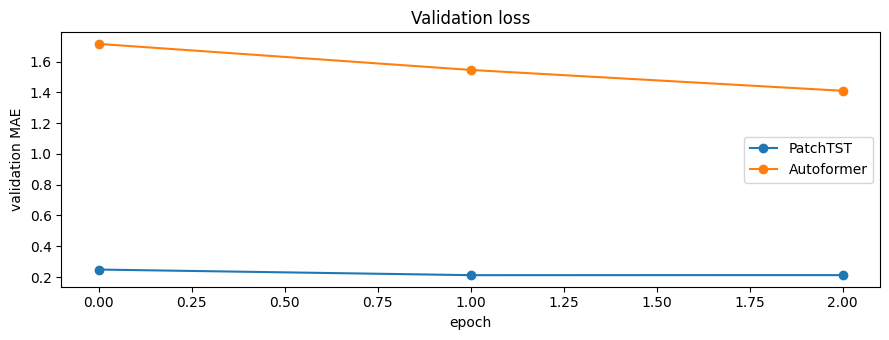

In [6]:
plt.figure(figsize=(9, 3.5))
for name, history in histories.items():
    plt.plot(history.history["val_loss"], marker="o", label=name)
plt.xlabel("epoch")
plt.ylabel("validation MAE")
plt.legend()
plt.title("Validation loss")
plt.tight_layout()
plt.show()

## 5. Evaluate
Run eager inference, verify the requested horizon, and report point-forecast MAE/MSE.

In [7]:
predictions, rows = {}, []
for name, model in models.items():
    pred = model(tf.convert_to_tensor(val_x), training=False).numpy()
    assert pred.shape == val_y.shape
    assert np.isfinite(pred).all()
    predictions[name] = pred
    error = pred - val_y
    rows.append({"model": name, "MAE": np.abs(error).mean(), "MSE": np.square(error).mean()})
pd.DataFrame(rows).set_index("model")

,MAE,MSE
model,,
PatchTST,0.212383,0.106089
Autoformer,1.410068,4.846414


## 6. Plot forecasts

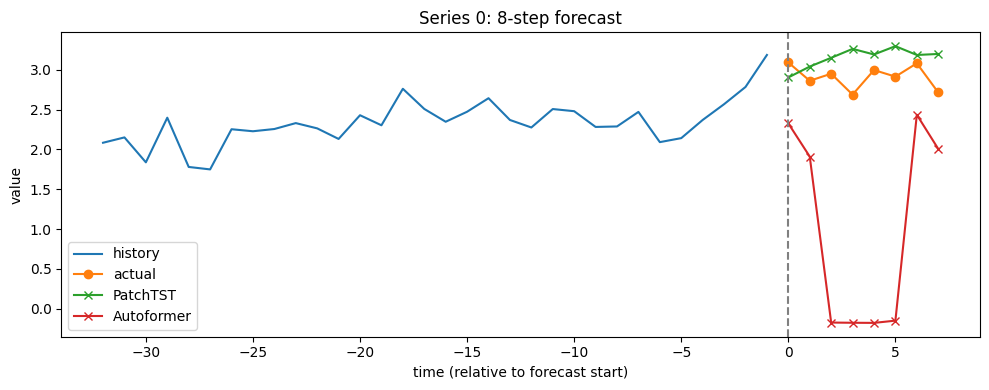

In [8]:
series_id = 0
history_axis = np.arange(-ENCODER_LENGTH, 0)
forecast_axis = np.arange(PREDICTION_LENGTH)
plt.figure(figsize=(10, 4))
plt.plot(history_axis, val_x[series_id, :, 0], label="history")
plt.plot(forecast_axis, val_y[series_id, :, 0], marker="o", label="actual")
for name, pred in predictions.items():
    plt.plot(forecast_axis, pred[series_id, :, 0], marker="x", label=name)
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("time (relative to forecast start)")
plt.ylabel("value")
plt.legend()
plt.title(f"Series {series_id}: {PREDICTION_LENGTH}-step forecast")
plt.tight_layout()
plt.show()